<h2 dir="rtl" style="text-align: right;">חלק 1 - הקדמה</h2>

<div dir="rtl" style="text-align: right;">
<h3>פרטי הסטודנטים</h3>
<p>אדר ר 4586</p>
<p>יוסף מ 5031</p>

<h3>שימוש בכלי AI</h3>
<p>במהלך העבודה נעזרנו ב-AI לצורך הבנה תיאורטית של האלגוריתם, דיבוג שגיאות (ובכלל זה בדיקות סינטקס), היכרות עם פקודות ופונקציות והבנת מדדי ההערכה.</p>
<p>פרומפטים לדוגמה בהם השתמשנו:</p>
<ul>
<li>תסביר log probabilities בנאיב בייס + מה זה laplace smoothing</li>
<li>keyerror בפנדס מה לעשות אני שולף טקסט מ-df</li>
<li>macro או micro f1 מה ההבדל</li>
</ul>

<h3>הסבר על הבעיה וה-Dataset</h3>
<p>במטלה זו נבצע משימת סיווג טקסט (Classification) על גבי הנתונים "OTT Movies & Series Dataset" מ-Kaggle.</p>
<p>המטרה שלנו היא לבנות מודל למידת מכונה (Naive Bayes) שיודע לחזות את ז'אנר הסרט או הסדרה (Comedy או Drama) על סמך תקציר העלילה (description) בלבד.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score, classification_report, matthews_corrcoef, confusion_matrix

df = pd.read_csv('ott_movies_clean_unique.csv')
df = df[(df['genre'] == 'Comedy') | (df['genre'] == 'Drama')]

<p dir="rtl" style="text-align: right;">ב-dataset הספציפי שבחרנו אין חלוקה מובנית ל-Train ו-Test ב-Kaggle, ולכן ביצענו את החלוקה בעצמנו.</p>

In [2]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
display(train_set.head())
display(test_set.head())

,content_id,title,type,genre,platform,country,language,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,tags,combined_features,description,poster_url
1527,C101518,Broken Empire 1518,Series,Comedy,Hotstar,India,Korean,2021,965,7.4,82464,7.38,1326.30,608.58,572.36,"Comedy,Hotstar,Series,Korean",Comedy Hotstar Series Broken Empire 1518 is a ...,Broken Empire 1518 is a comedy series on Hotst...,https://via.placeholder.com/150
13,C101914,Crimson Truth 1914,Series,Comedy,Prime Video,South Korea,English,2021,1626,8.4,194213,8.36,5263.17,1623.62,1847.91,"Comedy,Prime Video,Series,English",Comedy Prime Video Series Crimson Truth 1914 i...,Crimson Truth 1914 is a comedy series on Prime...,https://via.placeholder.com/150
1425,C100421,Broken Empire 421,Series,Drama,Netflix,South Korea,German,2018,1221,8.2,91151,8.14,1854.92,741.97,632.05,"Drama,Netflix,Series,German",Drama Netflix Series Broken Empire 421 is a dr...,Broken Empire 421 is a drama series on Netflix...,https://via.placeholder.com/150
2068,C101463,Last Kingdom 1463,Series,Comedy,Hotstar,Spain,Korean,2021,557,7.7,31899,7.61,296.13,242.75,252.32,"Comedy,Hotstar,Series,Korean",Comedy Hotstar Series Last Kingdom 1463 is a c...,Last Kingdom 1463 is a comedy series on Hotsta...,https://via.placeholder.com/150
1400,C101664,Lost Signal 1664,Series,Drama,Prime Video,India,German,2020,1504,7.1,103170,7.10,2586.13,732.51,646.71,"Drama,Prime Video,Series,German",Drama Prime Video Series Lost Signal 1664 is a...,Lost Signal 1664 is a drama series on Prime Vi...,https://via.placeholder.com/150


,content_id,title,type,genre,platform,country,language,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,tags,combined_features,description,poster_url
1085,C101973,Lost Signal 1973,Series,Comedy,Prime Video,South Korea,German,2017,1144,9.3,80163,9.16,1528.44,734.29,805.13,"Comedy,Prime Video,Series,German",Comedy Prime Video Series Lost Signal 1973 is ...,Lost Signal 1973 is a comedy series on Prime V...,https://via.placeholder.com/150
1781,C102150,Shadow Realm 2150,Movie,Comedy,Netflix,India,Spanish,2023,168,7.8,52585,7.73,147.24,406.48,434.64,"Comedy,Netflix,Movie,Spanish",Comedy Netflix Movie Shadow Realm 2150 is a co...,Shadow Realm 2150 is a comedy movie on Netflix...,https://via.placeholder.com/150
1926,C102077,Echoes of Time 2077,Movie,Drama,Hotstar,Germany,German,2015,144,7.8,47250,7.72,113.40,364.77,345.90,"Drama,Hotstar,Movie,German",Drama Hotstar Movie Echoes of Time 2077 is a d...,Echoes of Time 2077 is a drama movie on Hotsta...,https://via.placeholder.com/150
134,C101148,Lost Signal 1148,Series,Drama,Netflix,UK,English,2015,954,9.2,138176,9.12,2197.00,1260.17,1509.95,"Drama,Netflix,Series,English",Drama Netflix Series Lost Signal 1148 is a dra...,"Lost Signal 1148 is a drama series on Netflix,...",https://via.placeholder.com/150
1236,C100829,Crimson Truth 829,Series,Comedy,Prime Video,Germany,Hindi,2020,1971,7.8,94125,7.76,3092.01,730.41,735.39,"Comedy,Prime Video,Series,Hindi",Comedy Prime Video Series Crimson Truth 829 is...,Crimson Truth 829 is a comedy series on Prime ...,https://via.placeholder.com/150


<h2 dir="rtl" style="text-align: right;">חלק 2 - Feature Engineering</h2>
<div dir="rtl" style="text-align: right;">
<p>במקום לעבוד עם הטקסט הגולמי, החלטנו להתנסות ב-3 שיטות preprocessing שונות ולראות איזו מהן עובדת הכי טוב במודל שלנו:</p>
<ul>
<li>Basic - מוריד אותיות קטנות + מסיר תווים מיוחדים. זה ה-baseline שלנו.</li>
<li>Keep Numbers - אותו דבר אבל שומר מספרים. שמנו לב שבכותרות מופיעות שנים ומספרים (למשל 1518, 1914), ורצינו לבדוק אם זה תורם.</li>
<li>No Stopwords - מסיר את המילים הנפוצות כמו is, a, the, of, וגם את המילים movie ו-series שלא נושאות מידע על הז'אנר.</li>
</ul>
<p>בכל שלוש השיטות אנחנו מסירים את המילים 'comedy' ו-'drama' מהטקסט - בגלל שראינו שהן מופיעות בתוך ה-description עצמו, ואם נשאיר אותן זה למעשה data leakage של התווית למודל.</p>
</div>

In [3]:
def fe_basic(text):
    words = re.sub(r'[^a-z\s]', '', text.lower()).split()
    words = [w for w in words if w not in ('comedy', 'drama')]
    return words

def fe_keep_numbers(text):
    words = re.sub(r'[^a-z0-9\s]', '', text.lower()).split()
    words = [w for w in words if w not in ('comedy', 'drama')]
    return words

def fe_no_stopwords(text):
    words = re.sub(r'[^a-z\s]', '', text.lower()).split()
    stop = {'is', 'a', 'an', 'the', 'and', 'on', 'in', 'of', 'to', 'with', 'movie', 'series',
            'comedy', 'drama'}
    return [w for w in words if w not in stop]

fe_methods = {'Basic': fe_basic, 'Keep Numbers': fe_keep_numbers, 'No Stopwords': fe_no_stopwords}

In [4]:
print("train examples:")
for i, text in enumerate(train_set['description'].head(3).tolist()):
    print("sample", i+1, ":", text[:70])
    print("  basic:       ", fe_basic(text)[:6])
    print("  keep numbers:", fe_keep_numbers(text)[:6])
    print("  no stopwords:", fe_no_stopwords(text)[:6])
    print()

print("test examples:")
for i, text in enumerate(test_set['description'].head(3).tolist()):
    print("sample", i+1, ":", text[:70])
    print("  basic:       ", fe_basic(text)[:6])
    print("  keep numbers:", fe_keep_numbers(text)[:6])
    print("  no stopwords:", fe_no_stopwords(text)[:6])
    print()

train examples:
sample 1 : Broken Empire 1518 is a comedy series on Hotstar, featuring intense st
  basic:        ['broken', 'empire', 'is', 'a', 'series', 'on']
  keep numbers: ['broken', 'empire', '1518', 'is', 'a', 'series']
  no stopwords: ['broken', 'empire', 'hotstar', 'featuring', 'intense', 'storytelling']

sample 2 : Crimson Truth 1914 is a comedy series on Prime Video, featuring intens
  basic:        ['crimson', 'truth', 'is', 'a', 'series', 'on']
  keep numbers: ['crimson', 'truth', '1914', 'is', 'a', 'series']
  no stopwords: ['crimson', 'truth', 'prime', 'video', 'featuring', 'intense']

sample 3 : Broken Empire 421 is a drama series on Netflix, featuring intense stor
  basic:        ['broken', 'empire', 'is', 'a', 'series', 'on']
  keep numbers: ['broken', 'empire', '421', 'is', 'a', 'series']
  no stopwords: ['broken', 'empire', 'netflix', 'featuring', 'intense', 'storytelling']

test examples:
sample 1 : Lost Signal 1973 is a comedy series on Prime Video, featuring int

<h2 dir="rtl" style="text-align: right;">חלק 3 - מימוש אלגוריתם למידה</h2>
<div dir="rtl" style="text-align: right;">
<p>בחרנו לממש Naive Bayes מאפס. הרעיון בבסיס: לכל מילה אנחנו סופרים כמה פעמים היא הופיעה בכל אחת מהמחלקות (Comedy ו-Drama), ובחיזוי מחשבים לכל מחלקה את ההסתברות שהטקסט שייך אליה לפי המילים שבו.</p>

<p><b>למה log probabilities ולא הסתברויות רגילות?</b><br>
כשמכפילים הרבה מספרים קטנים (כל ההסתברויות של המילים), המספר מהר מאוד נהיה כל כך קטן שהמחשב פשוט מעגל אותו ל-0 (underflow). אם משתמשים בלוג, כפל הופך לחיבור והבעיה נעלמת.</p>

<p><b>שני ה-hyperparameters שהוספנו:</b></p>
<ul>
<li><code>alpha</code> - Laplace smoothing. אם מילה מסוימת לא הופיעה בכלל ב-train עבור מחלקה, ההסתברות שלה היא 0 ומאפסת את כל המכפלה. ה-alpha "מוסיף" קצת מסה לכל מילה כדי שזה לא יקרה.</li>
<li><code>fit_prior</code> - אם True משתמשים בהתפלגות המחלקות מה-train (כמה Comedy וכמה Drama יש בפועל); אם False מניחים 50/50.</li>
</ul>
</div>

In [5]:
class MyNaiveBayes:
    def __init__(self, alpha=1.0, fit_prior=True):
        self.alpha = alpha
        self.fit_prior = fit_prior
        self.comedy_words = {}
        self.drama_words = {}
        self.comedy_docs = 0
        self.drama_docs = 0
        self.comedy_total = 0
        self.drama_total = 0

    def fit(self, X_train, y_train):
        for i in range(len(X_train)):
            words = X_train[i]
            label = y_train[i]
            
            if label == 'Comedy':
                self.comedy_docs += 1
                for word in words:
                    if word in self.comedy_words:
                        self.comedy_words[word] += 1
                    else:
                        self.comedy_words[word] = 1
                    self.comedy_total += 1
            else:
                self.drama_docs += 1
                for word in words:
                    if word in self.drama_words:
                        self.drama_words[word] += 1
                    else:
                        self.drama_words[word] = 1
                    self.drama_total += 1

    def predict(self, X_test):
        total_docs = self.comedy_docs + self.drama_docs
        if self.fit_prior:
            prior_comedy = self.comedy_docs / total_docs
            prior_drama = self.drama_docs / total_docs
        else:
            prior_comedy = 0.5
            prior_drama = 0.5
        
        all_words = []
        for word in self.comedy_words:
            all_words.append(word)
        for word in self.drama_words:
            all_words.append(word)
        vocab_size = len(set(all_words))
        
        predictions = []
        
        for words in X_test:
            log_prob_comedy = np.log(prior_comedy)
            log_prob_drama = np.log(prior_drama)
            
            for word in words:
                if word in self.comedy_words:
                    count_comedy = self.comedy_words[word]
                else:
                    count_comedy = 0
                
                if word in self.drama_words:
                    count_drama = self.drama_words[word]
                else:
                    count_drama = 0
                
                p_word_comedy = (count_comedy + self.alpha) / (self.comedy_total + self.alpha * vocab_size)
                p_word_drama = (count_drama + self.alpha) / (self.drama_total + self.alpha * vocab_size)
                
                log_prob_comedy = log_prob_comedy + np.log(p_word_comedy)
                log_prob_drama = log_prob_drama + np.log(p_word_drama)
            
            if log_prob_comedy > log_prob_drama:
                predictions.append('Comedy')
            else:
                predictions.append('Drama')
        
        return predictions

<h2 dir="rtl" style="text-align: right;">חלק 6א - Grid Search + K-Fold Cross Validation</h2>
<p dir="rtl" style="text-align: right;">בשלב הראשון בודקים רק את ה-hyperparameter alpha על שיטת ה-FE הבסיסית, כדי להבין את טווח הערכים שמתאים. בחלק 6ב + 6ג נרחיב את הניסוי לקומבינציה מלאה (FE + alpha + fit_prior), והקומבינציה הטובה ביותר משם תשמש לאימון בחלק 4.</p>

In [6]:
alphas_to_test = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
X_train_clean = train_set['description'].apply(fe_basic).values
y_train_labels = train_set['genre'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_alpha = None
best_f1 = -1
results = []

for alpha in alphas_to_test:
    cv_scores = []
    for train_index, val_index in kf.split(X_train_clean):
        X_train_fold = X_train_clean[train_index]
        y_train_fold = y_train_labels[train_index]
        X_val_fold = X_train_clean[val_index]
        y_val_fold = y_train_labels[val_index]
        
        model_cv = MyNaiveBayes(alpha=alpha)
        model_cv.fit(X_train_fold, y_train_fold)
        
        predictions_cv = model_cv.predict(X_val_fold)
        fold_f1 = f1_score(y_val_fold, predictions_cv, average='macro')
        cv_scores.append(fold_f1)
        
    avg_macro_f1 = np.mean(cv_scores)
    results.append({'Alpha': alpha, 'Avg_Macro_F1': avg_macro_f1})
    
    print("alpha:", alpha, "| f1:", round(avg_macro_f1, 4))
    
    if avg_macro_f1 > best_f1:
        best_f1 = avg_macro_f1
        best_alpha = alpha

print("best alpha:", best_alpha, "| f1:", round(best_f1, 4))

results_df = pd.DataFrame(results)
display(results_df)

alpha: 0.1 | f1: 0.4769
alpha: 0.5 | f1: 0.4769
alpha: 1.0 | f1: 0.4769
alpha: 2.0 | f1: 0.4823
alpha: 5.0 | f1: 0.4841
alpha: 10.0 | f1: 0.484
best alpha: 5.0 | f1: 0.4841


,Alpha,Avg_Macro_F1
0,0.1,0.476916
1,0.5,0.476916
2,1.0,0.476916
3,2.0,0.482326
4,5.0,0.484104
5,10.0,0.483987


<h2 dir="rtl" style="text-align: right;">חלק 6ב + 6ג - התנסות ב-Feature Engineering ו-Hyperparameters</h2>
<div dir="rtl" style="text-align: right;">
<p>עכשיו אנחנו רצים על המכפלה הקרטזית המלאה של כל הקומבינציות:</p>
<p>3 שיטות FE × 3 ערכי alpha × 2 ערכי fit_prior = 18 קומבינציות</p>

<p>בכל קומבינציה אנחנו לא בודקים על חלוקה אחת בלבד - אלא מריצים 5-Fold Cross Validation:</p>
<ul>
<li>מחלקים את ה-trainset ל-5 חלקים שווים</li>
<li>בכל איטרציה משתמשים ב-4 חלקים לאימון ו-1 ל-validation</li>
<li>מקבלים 5 ציוני macro-F1 (אחד לכל fold)</li>
<li>הציון הסופי של הקומבינציה הוא הממוצע של ה-5</li>
</ul>

<p>בצורה הזאת אנחנו לא תלויים בחלוקה מקרית אחת ספציפית שיכולה להטעות, וחשוב מכך - ה-test set לא נוגע בכלל בשלב הזה ונשמר נקי לסוף.</p>
</div>

In [7]:
alphas_to_test = [0.1, 1.0, 5.0]
fit_priors_to_test = [True, False] 
y_train_labels = train_set['genre'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = []
best_f1 = -1
best_fe = None
best_a = None
best_p = None

for fe_name, fe_func in fe_methods.items():
    current_X_train = train_set['description'].apply(fe_func).values
    
    for alpha in alphas_to_test:
        for prior in fit_priors_to_test:
            cv_scores = []
            
            for train_index, val_index in kf.split(current_X_train):
                X_train_fold = current_X_train[train_index]
                y_train_fold = y_train_labels[train_index]
                X_val_fold = current_X_train[val_index]
                y_val_fold = y_train_labels[val_index]
    
                model = MyNaiveBayes(alpha=alpha, fit_prior=prior)
                model.fit(X_train_fold, y_train_fold)
                fold_preds = model.predict(X_val_fold)
                fold_f1 = f1_score(y_val_fold, fold_preds, average='macro')
                cv_scores.append(fold_f1)
                
            avg_macro_f1 = np.mean(cv_scores)
            
            all_results.append({
                'FE_Method': fe_name,
                'Alpha': alpha,
                'Fit_Prior': prior,
                'Avg_Macro_F1': avg_macro_f1
            })
            
            if avg_macro_f1 > best_f1:
                best_f1 = avg_macro_f1
                best_fe = fe_name
                best_a = alpha
                best_p = prior

df_results = pd.DataFrame(all_results)
display(df_results)
print("best combo: FE=", best_fe, "alpha=", best_a, "prior=", best_p)
print("f1:", round(best_f1, 4))

,FE_Method,Alpha,Fit_Prior,Avg_Macro_F1
0,Basic,0.1,True,0.476916
1,Basic,0.1,False,0.478963
2,Basic,1.0,True,0.476916
3,Basic,1.0,False,0.478963
4,Basic,5.0,True,0.484104
5,Basic,5.0,False,0.479023
6,Keep Numbers,0.1,True,0.478963
7,Keep Numbers,0.1,False,0.478963
8,Keep Numbers,1.0,True,0.482326
9,Keep Numbers,1.0,False,0.476916


best combo: FE= Basic alpha= 5.0 prior= True
f1: 0.4841


<h2 dir="rtl" style="text-align: right;">חלק 4 - אימון המודל</h2>
<div dir="rtl" style="text-align: right;">
<p>הקומבינציה הכי טובה שיצאה מה-cross validation (ראו את הפלט של חלק 6ב+6ג למעלה) משמשת אותנו עכשיו לאימון על כל ה-trainset. כמו שמסמך המטלה מנחה, אנחנו מאמנים מודל חדש עם הפרמטרים האלה על כל הדאטה ולא רק על 4 fold כמו בשלב ה-CV.</p>
</div>

In [8]:
df_sorted = df_results.sort_values(by='Avg_Macro_F1', ascending=False).reset_index(drop=True)
best_row = df_sorted.iloc[0]
best_fe_name = best_row['FE_Method']
best_fe_func = fe_methods[best_fe_name]
best_alpha = best_row['Alpha']
best_prior = best_row['Fit_Prior']

print("using best combo from grid search:")
print("  FE:    ", best_fe_name)
print("  alpha: ", best_alpha)
print("  prior: ", best_prior)
print()

my_model = MyNaiveBayes(alpha=best_alpha, fit_prior=best_prior)
X_train_clean = train_set['description'].apply(best_fe_func).values
y_train_genres = train_set['genre'].values
my_model.fit(X_train_clean, y_train_genres)
print("fit done")

print("train samples:")
for i, text in enumerate(train_set['description'].head(2).tolist()):
    print("sample", i+1)
    print("  before:", text)
    print("  after: ", best_fe_func(text))

print("test samples:")
for i, text in enumerate(test_set['description'].head(2).tolist()):
    print("sample", i+1)
    print("  before:", text)
    print("  after: ", best_fe_func(text))

X_test_clean = test_set['description'].apply(best_fe_func).values
my_predictions = my_model.predict(X_test_clean)
print("predictions:", len(my_predictions))

using best combo from grid search:
  FE:     Basic
  alpha:  5.0
  prior:  True

fit done
train samples:
sample 1
  before: Broken Empire 1518 is a comedy series on Hotstar, featuring intense storytelling and engaging characters.
  after:  ['broken', 'empire', 'is', 'a', 'series', 'on', 'hotstar', 'featuring', 'intense', 'storytelling', 'and', 'engaging', 'characters']
sample 2
  before: Crimson Truth 1914 is a comedy series on Prime Video, featuring intense storytelling and engaging characters.
  after:  ['crimson', 'truth', 'is', 'a', 'series', 'on', 'prime', 'video', 'featuring', 'intense', 'storytelling', 'and', 'engaging', 'characters']
test samples:
sample 1
  before: Lost Signal 1973 is a comedy series on Prime Video, featuring intense storytelling and engaging characters.
  after:  ['lost', 'signal', 'is', 'a', 'series', 'on', 'prime', 'video', 'featuring', 'intense', 'storytelling', 'and', 'engaging', 'characters']
sample 2
  before: Shadow Realm 2150 is a comedy movie on Netf

<h2 dir="rtl" style="text-align: right;">חלק 5 - חיזוי ושערוך איכות</h2>
<div dir="rtl" style="text-align: right;">
<p>שלב הבדיקה הסופית. חשוב לשים לב לשני דברים:</p>
<ul>
<li>אנחנו מבצעים על ה-test set בדיוק אותו preprocessing שביצענו על ה-train (FE Basic).</li>
<li>ה-test set הזה לא נראה למודל אף פעם לפני, גם לא בשלב ה-cross validation - אז התוצאה כאן היא הערכה נקייה.</li>
</ul>
<p>נציג את 5 התחזיות הראשונות מול התוויות האמיתיות, ואחר כך את ציון ה-macro-F1 על כל ה-test set.</p>
</div>

In [9]:
sample_texts = test_set['description'].head(2).tolist()
for i, text in enumerate(sample_texts):
    print("sample", i+1)
    print("before:", text)
    print("after: ", best_fe_func(text))
    print()

y_test_real = test_set['genre'].values
print("first 5 predictions:")
for i in range(5):
    pred = my_predictions[i]
    real = y_test_real[i]
    ok = "OK" if pred == real else "WRONG"
    print("movie", i+1, "- real:", real, "predicted:", pred, "->", ok)

macro_f1 = f1_score(y_test_real, my_predictions, average='macro')
print("macro f1:", round(macro_f1, 4))

print(classification_report(y_test_real, my_predictions))

sample 1
before: Lost Signal 1973 is a comedy series on Prime Video, featuring intense storytelling and engaging characters.
after:  ['lost', 'signal', 'is', 'a', 'series', 'on', 'prime', 'video', 'featuring', 'intense', 'storytelling', 'and', 'engaging', 'characters']

sample 2
before: Shadow Realm 2150 is a comedy movie on Netflix, featuring intense storytelling and engaging characters.
after:  ['shadow', 'realm', 'is', 'a', 'movie', 'on', 'netflix', 'featuring', 'intense', 'storytelling', 'and', 'engaging', 'characters']

first 5 predictions:
movie 1 - real: Comedy predicted: Comedy -> OK
movie 2 - real: Comedy predicted: Drama -> WRONG
movie 3 - real: Drama predicted: Drama -> OK
movie 4 - real: Drama predicted: Comedy -> WRONG
movie 5 - real: Comedy predicted: Comedy -> OK
macro f1: 0.4326
              precision    recall  f1-score   support

      Comedy       0.35      0.37      0.36        62
       Drama       0.51      0.49      0.50        83

    accuracy                  

<h2 dir="rtl" style="text-align: right;">חלק 6ד - התאמות מיוחדות של ה-Data (Undersampling + Oversampling)</h2>
<div dir="rtl" style="text-align: right;">
<p>לפני שאנחנו סומכים על התוצאות, חשוב לבדוק אם יש imbalance בין המחלקות. אם למשל יש פי 3 יותר Comedy מ-Drama, המודל יכול פשוט לחזות תמיד Comedy ולקבל accuracy טוב בלי באמת ללמוד כלום.</p>
<p>נדגים גם undersampling וגם oversampling - הראשון מקצץ מהמחלקה הגדולה, השני משכפל דוגמאות מהמחלקה הקטנה - גם אם בסוף יתברר שבדאטה שלנו זה לא נדרש.</p>
</div>

In [10]:
print("original:")
print(train_set['genre'].value_counts())
print()

df_comedy = train_set[train_set['genre'] == 'Comedy']
df_drama = train_set[train_set['genre'] == 'Drama']

min_class_size = min(len(df_comedy), len(df_drama))
max_class_size = max(len(df_comedy), len(df_drama))
diff = max_class_size - min_class_size
print("class diff:", diff, "-> dataset is almost balanced, so balancing probably won't help much")
print()

df_comedy_under = df_comedy.sample(n=min_class_size, random_state=42)
df_drama_under = df_drama.sample(n=min_class_size, random_state=42)
train_set_under = pd.concat([df_comedy_under, df_drama_under]).sample(frac=1, random_state=42)
print("after undersampling:")
print(train_set_under['genre'].value_counts())
print()

df_comedy_over = df_comedy.sample(n=max_class_size, replace=True, random_state=42)
df_drama_over = df_drama.sample(n=max_class_size, replace=True, random_state=42)
train_set_over = pd.concat([df_comedy_over, df_drama_over]).sample(frac=1, random_state=42)
print("after oversampling:")
print(train_set_over['genre'].value_counts())
print()

X_test_clean = test_set['description'].apply(best_fe_func).values
y_test_real = test_set['genre'].values

model_under = MyNaiveBayes(alpha=best_alpha, fit_prior=best_prior)
X_train_under = train_set_under['description'].apply(best_fe_func).values
y_train_under = train_set_under['genre'].values
model_under.fit(X_train_under, y_train_under)
preds_under = model_under.predict(X_test_clean)
f1_under = f1_score(y_test_real, preds_under, average='macro')

model_over = MyNaiveBayes(alpha=best_alpha, fit_prior=best_prior)
X_train_over = train_set_over['description'].apply(best_fe_func).values
y_train_over = train_set_over['genre'].values
model_over.fit(X_train_over, y_train_over)
preds_over = model_over.predict(X_test_clean)
f1_over = f1_score(y_test_real, preds_over, average='macro')

f1_baseline = f1_score(y_test_real, my_predictions, average='macro')

print("f1 baseline (no balancing):", round(f1_baseline, 4))
print("f1 with undersampling:     ", round(f1_under, 4))
print("f1 with oversampling:      ", round(f1_over, 4))
print()
print("diff between classes:", diff)

original:
genre
Drama     291
Comedy    289
Name: count, dtype: int64

class diff: 2 -> dataset is almost balanced, so balancing probably won't help much

after undersampling:
genre
Comedy    289
Drama     289
Name: count, dtype: int64

after oversampling:
genre
Drama     291
Comedy    291
Name: count, dtype: int64

f1 baseline (no balancing): 0.4326
f1 with undersampling:      0.4326
f1 with oversampling:       0.3857

diff between classes: 2


<h2 dir="rtl" style="text-align: right;">חלק 6ה - בדיקת איכות מיוחדת (MCC + Confusion Matrix)</h2>
<div dir="rtl" style="text-align: right;">
<p>בנוסף ל-macro F1, השתמשנו בשני כלי הערכה נוספים:</p>
<ul>
<li>MCC (Matthews Correlation Coefficient) - מדד שלוקח בחשבון את כל ארבעת התאים של מטריצת הבלבול (TP, TN, FP, FN). הוא נחשב מאוזן יותר ממדדים אחרים כי הוא לא מוטה כשיש imbalance. הערכים שלו נעים בין -1 (חיזוי הפוך לחלוטין) ל-+1 (חיזוי מושלם), כאשר 0 שווה ערך לניחוש מקרי.</li>
<li>Confusion Matrix - מאפשר לראות באופן ויזואלי איפה המודל מתבלבל. אם לדוגמה הוא מסווג הרבה Comedy בתור Drama אבל לא להפך, נראה את זה בבירור בתא הספציפי.</li>
</ul>
</div>

MCC: -0.1344


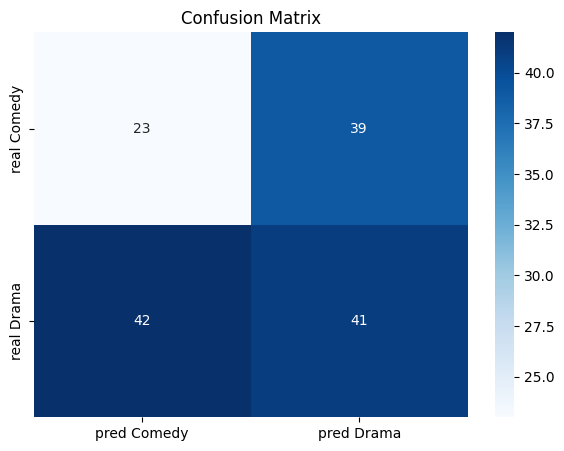

In [11]:
mcc_score = matthews_corrcoef(y_test_real, my_predictions)
print("MCC:", round(mcc_score, 4))

cm = confusion_matrix(y_test_real, my_predictions, labels=['Comedy', 'Drama'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred Comedy', 'pred Drama'],
            yticklabels=['real Comedy', 'real Drama'])
plt.title('Confusion Matrix')
plt.show()

<h2 dir="rtl" style="text-align: right;">חלק 6ו - Explainability (10 המילים הדומיננטיות לכל ז'אנר)</h2>
<div dir="rtl" style="text-align: right;">
<p>אחרי שיש לנו מודל שעובד, רצינו להבין מה הוא בעצם למד. ב-Naive Bayes זה יחסית פשוט להוציא מהמודל הסבר: לכל מילה במילון יש הסתברות מחושבת לכל מחלקה, ואנחנו פשוט שולפים את 10 המילים עם ההסתברות הכי גבוהה לכל ז'אנר.</p>
<p>זה מאפשר לנו לוודא שהמודל "תפס" משהו אמיתי שקשור לתוכן, ולא רק נצמד למילים גנריות שמופיעות בכל סוגי הטקסטים.</p>
</div>

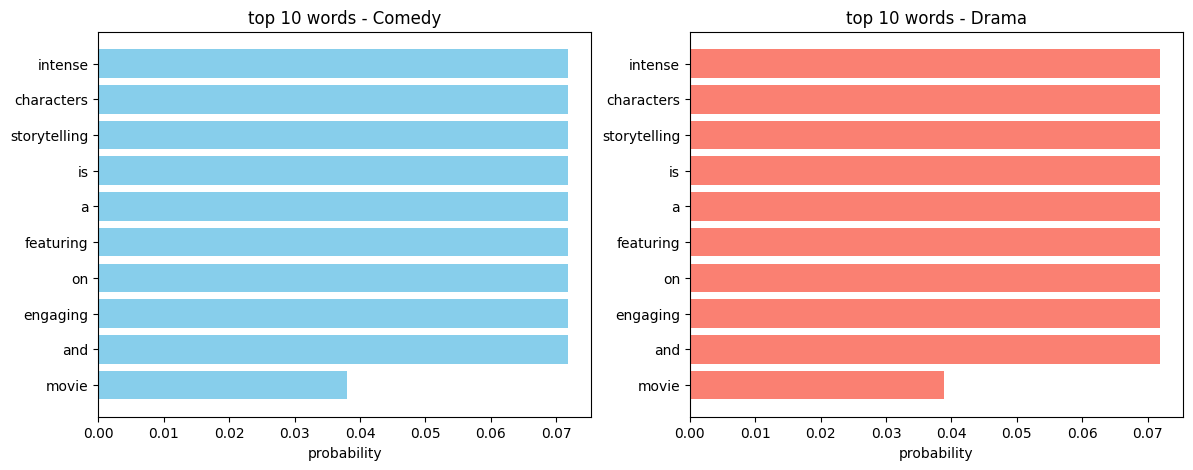

In [12]:
all_words = []
for word in my_model.comedy_words:
    all_words.append(word)
for word in my_model.drama_words:
    all_words.append(word)
all_words = set(all_words)
vocab_size = len(all_words)

comedy_probs = {}
drama_probs = {}

for word in all_words:
    if word in my_model.comedy_words:
        count_c = my_model.comedy_words[word]
    else:
        count_c = 0
    prob_c = (count_c + my_model.alpha) / (my_model.comedy_total + my_model.alpha * vocab_size)
    comedy_probs[word] = prob_c
    
    if word in my_model.drama_words:
        count_d = my_model.drama_words[word]
    else:
        count_d = 0
    prob_d = (count_d + my_model.alpha) / (my_model.drama_total + my_model.alpha * vocab_size)
    drama_probs[word] = prob_d

comedy_series = pd.Series(comedy_probs).sort_values(ascending=False).head(10)
drama_series = pd.Series(drama_probs).sort_values(ascending=False).head(10)

top_comedy = list(comedy_series.items())
top_drama = list(drama_series.items())

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
words_c, probs_c = zip(*top_comedy)
ax1.barh(words_c[::-1], probs_c[::-1], color='skyblue')
ax1.set_title('top 10 words - Comedy')
ax1.set_xlabel('probability')

ax2 = fig.add_subplot(1, 2, 2)
words_d, probs_d = zip(*top_drama)
ax2.barh(words_d[::-1], probs_d[::-1], color='salmon')
ax2.set_title('top 10 words - Drama')
ax2.set_xlabel('probability')

plt.show()

<h2 dir="rtl" style="text-align: right;">חלק 6ז - הצגת כל הניסויים</h2>
<div dir="rtl" style="text-align: right;">
<p>בתא הבא אנחנו מציגים את כל 18 הקומבינציות שנבדקו ב-grid search ממוין לפי macro-F1, יחד עם הקומבינציה המנצחת שהשתמשנו בה בחלק 4. זה מאפשר לראות את הטווח של תוצאות שהתקבלו ולהבין כמה הקומבינציה הטובה ביותר באמת בולטת מהאחרות.</p>
</div>

In [13]:
print("all results sorted by f1:")
df_sorted = df_results.sort_values(by='Avg_Macro_F1', ascending=False).reset_index(drop=True)
display(df_sorted)

best_row = df_sorted.iloc[0]
print()
print("best combination:")
print("  FE:    ", best_row['FE_Method'])
print("  alpha: ", best_row['Alpha'])
print("  prior: ", best_row['Fit_Prior'])
print("  f1:    ", round(best_row['Avg_Macro_F1'], 4))

all results sorted by f1:


,FE_Method,Alpha,Fit_Prior,Avg_Macro_F1
0,Basic,5.0,True,0.484104
1,Keep Numbers,1.0,True,0.482326
2,Keep Numbers,5.0,True,0.482006
3,No Stopwords,0.1,False,0.480219
4,No Stopwords,1.0,False,0.480219
5,No Stopwords,5.0,True,0.479113
6,Basic,5.0,False,0.479023
7,Basic,0.1,False,0.478963
8,Keep Numbers,0.1,True,0.478963
9,Basic,1.0,False,0.478963



best combination:
  FE:     Basic
  alpha:  5.0
  prior:  True
  f1:     0.4841
